In [1]:
import numpy as np
import matplotlib.pyplot as plt
import src.routines.tomo_fusion.tools.plotting_fcts as tomo_plots
import copy
from src.routines.rt_roi_prad import RtPradROI
from scipy import stats

/home/dhamm/miniconda3/envs/rt-paper/lib/python3.12/site-packages/pyxu/info/plugin.py:70: ContributionWarning: Plugin `pyxu_diffops.operator:AnisCoherenceEnhancingDiffusionOp` loaded.
  warnings.warn(msg, pxw.ContributionWarning)
/home/dhamm/miniconda3/envs/rt-paper/lib/python3.12/site-packages/pyxu/info/plugin.py:70: ContributionWarning: Plugin `pyxu_diffops.operator:AnisDiffusionOp` loaded.
  warnings.warn(msg, pxw.ContributionWarning)
/home/dhamm/miniconda3/envs/rt-paper/lib/python3.12/site-packages/pyxu/info/plugin.py:70: ContributionWarning: Plugin `pyxu_diffops.operator:AnisEdgeEnhancingDiffusionOp` loaded.
  warnings.warn(msg, pxw.ContributionWarning)
/home/dhamm/miniconda3/envs/rt-paper/lib/python3.12/site-packages/pyxu/info/plugin.py:70: ContributionWarning: Plugin `pyxu_diffops.operator:CurvaturePreservingDiffusionOp` loaded.
  warnings.warn(msg, pxw.ContributionWarning)
/home/dhamm/miniconda3/envs/rt-paper/lib/python3.12/site-packages/pyxu/info/plugin.py:70: ContributionWarn

In [2]:
# LSN configuration
lsn_idxs = np.array([85184, 85185, 85269, 85270, 86554, 86572, 86605, 86735, 86850, 87081])
# USN configuration
usn_idxs = np.array([85432, 85434, 86210, 86462, 86585, 86591, 86838, 86839, 87063, 87076])
# NT configuration
nt_idxs = np.array([84762, 84764, 85138, 85997, 86063, 86088, 86089, 86289, 86436, 86744])
# XPT configuration
xpt_idxs = np.array([85820, 85199, 85350, 85353, 85357, 85815, 85816, 85818, 85819, 87080])
# LL configuration
ll_idxs = np.array([85166, 85174, 85192, 85194, 85439, 85487, 85489, 86015, 86117, 86985])


# all shot numbers
all_shot_idxs = np.hstack((lsn_idxs, usn_idxs, nt_idxs, xpt_idxs, ll_idxs))

In [3]:
shot_information = np.load('shot_infos.npy', allow_pickle=True).item()

In [4]:
diverted_time_range = np.load('diverted_time_ranges.npy', allow_pickle=True).item()

In [5]:
data = []


for shot_idx in all_shot_idxs:
    data.append(np.load('campaign_study_results/shot_'+str(shot_idx)+'.npy', allow_pickle=True).item())
    

In [6]:
# handle oscillating x-point cases

idx_osc = 22
prads_roi_inversions = data[idx_osc]["prads_roi_inversions"]
prads_inv_div_main = copy.deepcopy(prads_roi_inversions[2:,:])
prads_roi_inversions[2,:] = np.min(prads_inv_div_main, axis=0)
prads_roi_inversions[3,:] = np.max(prads_inv_div_main, axis=0)
data[idx_osc]["prads_roi_inversions"] = prads_roi_inversions

idx_osc = 23
prads_roi_inversions = data[idx_osc]["prads_roi_inversions"]
prads_inv_div_main = copy.deepcopy(prads_roi_inversions[2:,:])
prads_roi_inversions[2,:] = np.min(prads_inv_div_main, axis=0)
prads_roi_inversions[3,:] = np.max(prads_inv_div_main, axis=0)
data[idx_osc]["prads_roi_inversions"] = prads_roi_inversions

In [7]:
# introduce also how many standard deviations truth is from mean

relative_errors = []
mses = []
pearson_rs = []
nb_stds_nosign = []

relative_errors_prev = []
mses_prev = []
pearson_rs_prev = []
nb_stds_nosign_prev = []

relative_errors_prev_stable = []
mses_prev_stable = []
pearson_rs_prev_stable = []
nb_stds_nosign_prev_stable = []

relative_errors_basic = []
mses_basic = []
pearson_rs_basic = []
nb_stds_nosign_basic = []


idx_start = 5
idxs_end_to_discard = 4

for idx in range(len(data)):
    prads_roi = copy.deepcopy(data[idx]["prads_roi"])[:, idx_start:-idxs_end_to_discard]
    stds_prad_roi = copy.deepcopy(data[idx]["stds_prad_roi"])[:, idx_start:-idxs_end_to_discard]
    if data[idx]["shot_prev_bad_channels_differ"]:
        prads_roi_prev = copy.deepcopy(data[idx]["prads_roi_prev"])[:, idx_start:-idxs_end_to_discard]
        stds_prad_roi_prev = copy.deepcopy(data[idx]["stds_prad_roi_prev"])[:, idx_start:-idxs_end_to_discard]
    else:
        prads_roi_prev = copy.deepcopy(prads_roi)
        stds_prad_roi_prev = copy.deepcopy(stds_prad_roi)
    prads_roi_prev_stable = copy.deepcopy(data[idx]["prads_roi_prev_stable"])[:, idx_start:-idxs_end_to_discard]
    stds_roi_prev_stable = copy.deepcopy(data[idx]["stds_roi_prev_stable"])[:, idx_start:-idxs_end_to_discard]
    prads_roi_basic = copy.deepcopy(data[idx]["prads_roi_basic"])[:, idx_start:-idxs_end_to_discard]
    stds_roi_basic = copy.deepcopy(data[idx]["stds_roi_basic"])[:, idx_start:-idxs_end_to_discard]
    inversion_times = data[idx]["inversion_times"][idx_start:-idxs_end_to_discard]
    prads_roi_inversions = data[idx]["prads_roi_inversions"][:, idx_start:-idxs_end_to_discard]
      
    # identify time range to be considered for diverted/main chamber Prad analysis
    if diverted_time_range["time_ranges"][0,idx] is None:
        idx_start_div = 0
        idx_end_div = -1
    else:
        idx_start_div = int(np.where((inversion_times - diverted_time_range["time_ranges"][0,idx]) >= 0)[0][0])
        idx_end_div = int(np.where((inversion_times - (diverted_time_range["time_ranges"][1,idx]-0.05)) <= 0)[0][-1]) + 1
    #print("Time range: {}s-{}s".format(inversion_times[idx_start_div], inversion_times[idx_end_div-1] ))

    relative_errors.append( (prads_roi - prads_roi_inversions) / prads_roi_inversions)
    mses.append((prads_roi - prads_roi_inversions)**2)
    rs_tot = stats.pearsonr(prads_roi[0,:].flatten(), prads_roi_inversions[0,:].flatten())
    rs_core = stats.pearsonr(prads_roi[1,:].flatten(), prads_roi_inversions[1,:].flatten())
    rs_div = stats.pearsonr(prads_roi[2,idx_start_div:idx_end_div].flatten(), prads_roi_inversions[2,idx_start_div:idx_end_div].flatten())
    rs_main = stats.pearsonr(prads_roi[3,idx_start_div:idx_end_div].flatten(), prads_roi_inversions[3,idx_start_div:idx_end_div].flatten())
    pearson_rs.append(np.array([rs_tot, rs_core, rs_div, rs_main]))
    nb_stds_nosign.append( np.abs(prads_roi - prads_roi_inversions)  / stds_prad_roi)

    relative_errors_prev.append( (prads_roi_prev - prads_roi_inversions) / prads_roi_inversions)
    mses_prev.append((prads_roi_prev - prads_roi_inversions)**2)
    rs_tot = stats.pearsonr(prads_roi_prev[0,:].flatten(), prads_roi_inversions[0,:].flatten())
    rs_core = stats.pearsonr(prads_roi_prev[1,:].flatten(), prads_roi_inversions[1,:].flatten())
    rs_div = stats.pearsonr(prads_roi_prev[2,idx_start_div:idx_end_div].flatten(), prads_roi_inversions[2,idx_start_div:idx_end_div].flatten())
    rs_main = stats.pearsonr(prads_roi_prev[3,idx_start_div:idx_end_div].flatten(), prads_roi_inversions[3,idx_start_div:idx_end_div].flatten())
    pearson_rs_prev.append(np.array([rs_tot, rs_core, rs_div, rs_main]))
    nb_stds_nosign_prev.append( np.abs(prads_roi_prev - prads_roi_inversions)  / stds_prad_roi_prev)
    
    relative_errors_prev_stable.append( (prads_roi_prev_stable - prads_roi_inversions) / prads_roi_inversions)
    mses_prev_stable.append((prads_roi_prev_stable - prads_roi_inversions)**2)
    rs_tot = stats.pearsonr(prads_roi_prev_stable[0,:].flatten(), prads_roi_inversions[0,:].flatten())
    rs_core = stats.pearsonr(prads_roi_prev_stable[1,:].flatten(), prads_roi_inversions[1,:].flatten())
    rs_div = stats.pearsonr(prads_roi_prev_stable[2,idx_start_div:idx_end_div].flatten(), prads_roi_inversions[2,idx_start_div:idx_end_div].flatten())
    rs_main = stats.pearsonr(prads_roi_prev_stable[3,idx_start_div:idx_end_div].flatten(), prads_roi_inversions[3,idx_start_div:idx_end_div].flatten())
    pearson_rs_prev_stable.append(np.array([rs_tot, rs_core, rs_div, rs_main]))
    nb_stds_nosign_prev_stable.append( np.abs(prads_roi_prev_stable - prads_roi_inversions)  / stds_roi_prev_stable)
    
    relative_errors_basic.append( (prads_roi_basic - prads_roi_inversions) / prads_roi_inversions)
    mses_basic.append((prads_roi_basic - prads_roi_inversions)**2)
    rs_tot = stats.pearsonr(prads_roi_basic[0,:].flatten(), prads_roi_inversions[0,:].flatten())
    rs_core = stats.pearsonr(prads_roi_basic[1,:].flatten(), prads_roi_inversions[1,:].flatten())
    rs_div = stats.pearsonr(prads_roi_basic[2,idx_start_div:idx_end_div].flatten(), prads_roi_inversions[2,idx_start_div:idx_end_div].flatten())
    rs_main = stats.pearsonr(prads_roi_basic[3,idx_start_div:idx_end_div].flatten(), prads_roi_inversions[3,idx_start_div:idx_end_div].flatten())
    pearson_rs_basic.append(np.array([rs_tot, rs_core, rs_div, rs_main]))
    nb_stds_nosign_basic.append( np.abs(prads_roi_basic - prads_roi_inversions)  / stds_roi_basic)


/tmp/ipykernel_27559/1943851142.py:52: RuntimeWarning: divide by zero encountered in divide
  relative_errors.append( (prads_roi - prads_roi_inversions) / prads_roi_inversions)
/tmp/ipykernel_27559/1943851142.py:61: RuntimeWarning: divide by zero encountered in divide
  relative_errors_prev.append( (prads_roi_prev - prads_roi_inversions) / prads_roi_inversions)
/tmp/ipykernel_27559/1943851142.py:70: RuntimeWarning: divide by zero encountered in divide
  relative_errors_prev_stable.append( (prads_roi_prev_stable - prads_roi_inversions) / prads_roi_inversions)
/tmp/ipykernel_27559/1943851142.py:79: RuntimeWarning: divide by zero encountered in divide
  relative_errors_basic.append( (prads_roi_basic - prads_roi_inversions) / prads_roi_inversions)


In [8]:
average_relative_errors = np.zeros((4,len(data)))
average_mse_errors = np.zeros((4,len(data)))
average_nb_stds_nosign = np.zeros((4,len(data))) 
avg_pearsons_r = np.zeros((4,len(data))) 

average_relative_errors_prev = np.zeros((4,len(data)))
average_mse_errors_prev = np.zeros((4,len(data)))
average_nb_stds_prev_nosign = np.zeros((4,len(data))) 
avg_pearsons_r_prev = np.zeros((4,len(data))) 

average_relative_errors_prev_stable = np.zeros((4,len(data)))
average_mse_errors_prev_stable = np.zeros((4,len(data)))
average_nb_stds_prev_stable_nosign = np.zeros((4,len(data))) 
avg_pearsons_r_prev_stable = np.zeros((4,len(data))) 

average_relative_errors_basic = np.zeros((4,len(data)))
average_mse_errors_basic = np.zeros((4,len(data)))
average_nb_stds_basic_nosign = np.zeros((4,len(data))) 
avg_pearsons_r_basic = np.zeros((4,len(data))) 

for i in range(len(data)):
    idx_start = 5
    idxs_end_to_discard = 4
    inversion_times = data[i]["inversion_times"][idx_start:-idxs_end_to_discard]
    # identify time range to be considered for diverted/main chamber Prad analysis
    if diverted_time_range["time_ranges"][0,i] is None:
        idx_start_div = 0
        idx_end_div = -1
    else:
        idx_start_div = int(np.where((inversion_times - diverted_time_range["time_ranges"][0,i]) >= 0)[0][0])
        idx_end_div = int(np.where((inversion_times - (diverted_time_range["time_ranges"][1,i]-0.05)) <= 0)[0][-1]) + 1
        
    # -------- ONLY GOOD CHANNELS ----------------
    # relative error
    average_relative_errors[0,i] = np.mean(relative_errors[i][0,:])
    average_relative_errors[1,i] = np.mean(relative_errors[i][1,:])    
    average_relative_errors[2,i] = np.mean(relative_errors[i][2,idx_start_div:idx_end_div])
    average_relative_errors[3,i] = np.mean(relative_errors[i][3,idx_start_div:idx_end_div])     
    # mse error
    average_mse_errors[0,i] = np.sqrt(np.mean(mses[i][0,:]))
    average_mse_errors[1,i] = np.sqrt(np.mean(mses[i][1,:]))
    average_mse_errors[2,i] = np.sqrt(np.mean(mses[i][2,idx_start_div:idx_end_div]))
    average_mse_errors[3,i] = np.sqrt(np.mean(mses[i][3,idx_start_div:idx_end_div]))
    # nb stds abs
    average_nb_stds_nosign[0,i] = np.mean(nb_stds_nosign[i][0,:])
    average_nb_stds_nosign[1,i] = np.mean(nb_stds_nosign[i][1,:])
    average_nb_stds_nosign[2,i] = np.mean(nb_stds_nosign[i][2,idx_start_div:idx_end_div])
    average_nb_stds_nosign[3,i] = np.mean(nb_stds_nosign[i][3,idx_start_div:idx_end_div])
    # pearson R
    avg_pearsons_r[0,i] = pearson_rs[i][0,0]
    avg_pearsons_r[1,i] = pearson_rs[i][1,0]
    avg_pearsons_r[2,i] = pearson_rs[i][2,0]
    avg_pearsons_r[3,i] = pearson_rs[i][3,0]
    
    # -------- GOOD CHANNELS FROM PREVIOUS SHOT ----------------
    # relative error
    average_relative_errors_prev[0,i] = np.mean(relative_errors_prev[i][0,:])
    average_relative_errors_prev[1,i] = np.mean(relative_errors_prev[i][1,:])    
    average_relative_errors_prev[2,i] = np.mean(relative_errors_prev[i][2,idx_start_div:idx_end_div])
    average_relative_errors_prev[3,i] = np.mean(relative_errors_prev[i][3,idx_start_div:idx_end_div])   
    # mse error
    average_mse_errors_prev[0,i] = np.sqrt(np.mean(mses_prev[i][0,:]))
    average_mse_errors_prev[1,i] = np.sqrt(np.mean(mses_prev[i][1,:]))
    average_mse_errors_prev[2,i] = np.sqrt(np.mean(mses_prev[i][2,idx_start_div:idx_end_div]))
    average_mse_errors_prev[3,i] = np.sqrt(np.mean(mses_prev[i][3,idx_start_div:idx_end_div]))
    # nb stds abs
    average_nb_stds_prev_nosign[0,i] = np.mean(nb_stds_nosign_prev[i][0,:])
    average_nb_stds_prev_nosign[1,i] = np.mean(nb_stds_nosign_prev[i][1,:])
    average_nb_stds_prev_nosign[2,i] = np.mean(nb_stds_nosign_prev[i][2,idx_start_div:idx_end_div])
    average_nb_stds_prev_nosign[3,i] = np.mean(nb_stds_nosign_prev[i][3,idx_start_div:idx_end_div])
   # pearson R
    avg_pearsons_r_prev[0,i] = pearson_rs_prev[i][0,0]
    avg_pearsons_r_prev[1,i] = pearson_rs_prev[i][1,0]
    avg_pearsons_r_prev[2,i] = pearson_rs_prev[i][2,0]
    avg_pearsons_r_prev[3,i] = pearson_rs_prev[i][3,0]
    
    # -------- GOOD CHANNELS FROM PREVIOUS SHOT MINUS KNOWN UNSTABLE CHORDS ----------------
        # relative error
    average_relative_errors_prev_stable[0,i] = np.mean(relative_errors_prev_stable[i][0,:])
    average_relative_errors_prev_stable[1,i] = np.mean(relative_errors_prev_stable[i][1,:])    
    average_relative_errors_prev_stable[2,i] = np.mean(relative_errors_prev_stable[i][2,idx_start_div:idx_end_div])
    average_relative_errors_prev_stable[3,i] = np.mean(relative_errors_prev_stable[i][3,idx_start_div:idx_end_div])  
    # mse error
    average_mse_errors_prev_stable[0,i] = np.sqrt(np.mean(mses_prev_stable[i][0,:]))
    average_mse_errors_prev_stable[1,i] = np.sqrt(np.mean(mses_prev_stable[i][1,:]))
    average_mse_errors_prev_stable[2,i] = np.sqrt(np.mean(mses_prev_stable[i][2,idx_start_div:idx_end_div]))
    average_mse_errors_prev_stable[3,i] = np.sqrt(np.mean(mses_prev_stable[i][3,idx_start_div:idx_end_div]))
    # nb stds abs
    average_nb_stds_prev_stable_nosign[0,i] = np.mean(nb_stds_nosign_prev_stable[i][0,:])
    average_nb_stds_prev_stable_nosign[1,i] = np.mean(nb_stds_nosign_prev_stable[i][1,:])
    average_nb_stds_prev_stable_nosign[2,i] = np.mean(nb_stds_nosign_prev_stable[i][2,idx_start_div:idx_end_div])
    average_nb_stds_prev_stable_nosign[3,i] = np.mean(nb_stds_nosign_prev_stable[i][3,idx_start_div:idx_end_div])
    # pearson R
    avg_pearsons_r_prev_stable[0,i] = pearson_rs_prev_stable[i][0,0]
    avg_pearsons_r_prev_stable[1,i] = pearson_rs_prev_stable[i][1,0]
    avg_pearsons_r_prev_stable[2,i] = pearson_rs_prev_stable[i][2,0]
    avg_pearsons_r_prev_stable[3,i] = pearson_rs_prev_stable[i][3,0]
    
    # -------- BASIC APPROACH, ALWAYS ALL CHANNELS EXCEPT 70,2,6,118  ----------------
    # relative error
    average_relative_errors_basic[0,i] = np.mean(relative_errors_basic[i][0,:])
    average_relative_errors_basic[1,i] = np.mean(relative_errors_basic[i][1,:])    
    average_relative_errors_basic[2,i] = np.mean(relative_errors_basic[i][2,idx_start_div:idx_end_div])
    average_relative_errors_basic[3,i] = np.mean(relative_errors_basic[i][3,idx_start_div:idx_end_div])   
    # mse error
    average_mse_errors_basic[0,i] = np.sqrt(np.mean(mses_basic[i][0,:]))
    average_mse_errors_basic[1,i] = np.sqrt(np.mean(mses_basic[i][1,:]))
    average_mse_errors_basic[2,i] = np.sqrt(np.mean(mses_basic[i][2,idx_start_div:idx_end_div]))
    average_mse_errors_basic[3,i] = np.sqrt(np.mean(mses_basic[i][3,idx_start_div:idx_end_div]))
    # nb stds abs
    average_nb_stds_basic_nosign[0,i] = np.mean(nb_stds_nosign_basic[i][0,:])
    average_nb_stds_basic_nosign[1,i] = np.mean(nb_stds_nosign_basic[i][1,:])
    average_nb_stds_basic_nosign[2,i] = np.mean(nb_stds_nosign_basic[i][2,idx_start_div:idx_end_div])
    average_nb_stds_basic_nosign[3,i] = np.mean(nb_stds_nosign_basic[i][3,idx_start_div:idx_end_div])
    # pearson R
    avg_pearsons_r_basic[0,i] = pearson_rs_basic[i][0,0]
    avg_pearsons_r_basic[1,i] = pearson_rs_basic[i][1,0]
    avg_pearsons_r_basic[2,i] = pearson_rs_basic[i][2,0]
    avg_pearsons_r_basic[3,i] = pearson_rs_basic[i][3,0]
    

# Figure 3

In [9]:
# select idx
idx = 3
print("Results for shot {}".format(all_shot_idxs[idx]))

Results for shot 85270


In [10]:
# tomographic reconstructions
good_channels = shot_information["shot_good_channels"][idx]
rt_prad = RtPradROI(shot_nb=int(all_shot_idxs[idx]), bolo_good_channels=good_channels, downsample=False, is_usn=False)
mask_types = ["total", "core", "divertor", "main_chamber"]
rt_prad.compute_roi_fbte_based_masks(time_range=None, mask_types=mask_types)
(inversion_times, inversions,
         prads_roi_inversions_tomo, _, liuqe_equils) = rt_prad.compute_baseline_tomographic_inversion(
            decimation_factor=1,
            sigma_err=2.5e-2, reg_param=1e1,
            anis_param=1e-2, with_positivity_constraint=False,
            mask_type="liuqe")

processing 0th/190 phantom
processing 10th/190 phantom
processing 20th/190 phantom
processing 30th/190 phantom
processing 40th/190 phantom
processing 50th/190 phantom
processing 60th/190 phantom
processing 70th/190 phantom
processing 80th/190 phantom
processing 90th/190 phantom
processing 100th/190 phantom
processing 110th/190 phantom
processing 120th/190 phantom
processing 130th/190 phantom
processing 140th/190 phantom
processing 150th/190 phantom
processing 160th/190 phantom
processing 170th/190 phantom
processing 180th/190 phantom


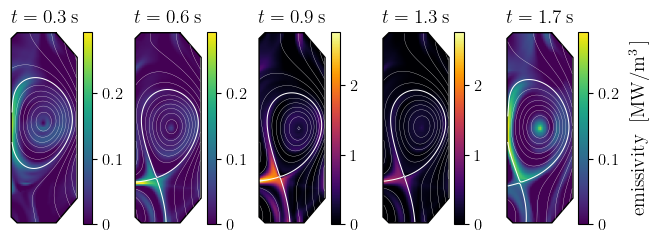

In [15]:
vmin=0
vmax=None

width_ratios = [1,1,1,1,1]

fig,ax=plt.subplots(1,5,figsize=(7.5,2.5), width_ratios=width_ratios)
plt.subplots_adjust(hspace=0.1, wspace=0.45)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    'text.latex.preamble': r"""\usepackage{bm}""",
})

idx_tbp = np.array([29,59,89,129,169], dtype=int)

vmax = None
vmin = 0


cbar_tick_parmas_list = []
cbar_tick_params={}
cbar_tick_params["labelsize"]=12
cbar_tick_params["label_labelsize"]=14
cbar_tick_params["yticks"]=[0, 1e5,2e5]
cbar_tick_params["yticklabels"]=[r"$0$", r"$0.1$", r"$0.2$"]
cbar_tick_params["label_labelsize_pad"] = 0.1
cbar_tick_parmas_list.append(cbar_tick_params)
cbar_tick_params={}
cbar_tick_params["labelsize"]=12
cbar_tick_params["label_labelsize"]=12
cbar_tick_params["yticks"]=[0, 1e5,2e5]
cbar_tick_params["yticklabels"]=[r"$0$", r"$0.1$", r"$0.2$"]
cbar_tick_params["label_labelsize_pad"] = 0.1
cbar_tick_parmas_list.append(cbar_tick_params)
cbar_tick_params={}
cbar_tick_params["labelsize"]=12
cbar_tick_params["label_labelsize"]=12
cbar_tick_params["yticks"]=[0, 1e6,2e6]
cbar_tick_params["yticklabels"]=[r"$0$", r"$1$", r"$2$"]
cbar_tick_params["label_labelsize_pad"] = 0.1
cbar_tick_parmas_list.append(cbar_tick_params)
cbar_tick_params={}
cbar_tick_params["labelsize"]=12
cbar_tick_params["label_labelsize"]=12
cbar_tick_params["yticks"]=[0, 1e6,2e6]
cbar_tick_params["yticklabels"]=[r"$0$", r"$1$", r"$2$"]
cbar_tick_params["label_labelsize_pad"] = 0.1
cbar_tick_parmas_list.append(cbar_tick_params)
cbar_tick_params={}
cbar_tick_params["labelsize"]=12
cbar_tick_params["label_labelsize"]=14
cbar_tick_params["yticks"]=[0, 1e5,2e5]
cbar_tick_params["yticklabels"]=[r"$0$", r"$0.1$", r"$0.2$"]
cbar_tick_params["label_labelsize_pad"] = 7
cbar_tick_parmas_list.append(cbar_tick_params)

vmaxs=[np.max(inversions[idx_tbp[-1], :, :]), np.max(inversions[idx_tbp[-1], :, :]),
       np.max(inversions[idx_tbp[2], :, :]), np.max(inversions[idx_tbp[2], :, :]),
       np.max(inversions[idx_tbp[-1], :, :])]
cmaps=["viridis", "viridis", "inferno", "inferno", "viridis"]

titles = [r"$t={:.1f}\,\mathrm{{s}}$".format(inversion_times[idx_tbp[0]]),
          r"$t={:.1f}\,\mathrm{{s}}$".format(inversion_times[idx_tbp[1]]),
          r"$t={:.1f}\,\mathrm{{s}}$".format(inversion_times[idx_tbp[2]]),
          r"$t={:.1f}\,\mathrm{{s}}$".format(inversion_times[idx_tbp[3]]),
          r"$t={:.1f}\,\mathrm{{s}}$".format(inversion_times[idx_tbp[4]])]

for i in range(1):
    for j in range(5):
        cbar_label = None if j<4 else r"$\mathrm{emissivity}\;\;[\mathrm{MW}/\mathrm{m}^3\,]$"
        tomo_plots.plot_profile(inversions[idx_tbp[j], :, :], tcv_plot_clip=True, contour_image=liuqe_equils[idx_tbp[j], :, :],
                                cmap=cmaps[j],
                         ax=ax[j], colorbar=True, contour_color="w", vmin=vmin, vmax=vmaxs[j], aspect="auto", levels=12, pad_cbar=0.05, cbar_tick_params=cbar_tick_parmas_list[j], cbar_label=cbar_label)
        ax[j].set_title(titles[j], fontsize=14)

#plt.savefig('figures/shot_85270_inversions_study.eps', format='eps', bbox_inches="tight")

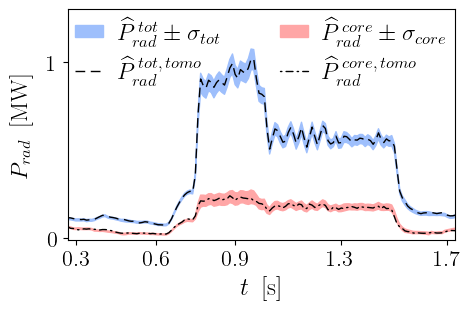

In [11]:
plt.figure(figsize=(5,3))

prads_roi = data[idx]["prads_roi"]
stds_prad_roi = data[idx]["stds_prad_roi"]
inversion_times = data[idx]["inversion_times"]
prads_roi_inversions = data[idx]["prads_roi_inversions"]

down_sampling_factor = 1
nb_stds = 1

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    'text.latex.preamble': r"""\usepackage{bm}""",
})

lower_bound = prads_roi[0,:] - nb_stds * stds_prad_roi[0, :]
upper_bound = prads_roi[0,:] + nb_stds * stds_prad_roi[0, :]
plt.fill_between(inversion_times[::down_sampling_factor], lower_bound[::down_sampling_factor], upper_bound[::down_sampling_factor], color=np.array([0.62,0.75,0.99]), label=r"$\widehat{P}_{rad}^{\,tot}\pm\sigma_{tot}$")
plt.plot(inversion_times[::down_sampling_factor], prads_roi_inversions[0,:].flatten()[::down_sampling_factor], 'k--', dashes=(7,4), linewidth=1, label=r"$\widehat{P}_{rad}^{\,tot,\,tomo}$")

lower_bound = prads_roi[1,:] - nb_stds * stds_prad_roi[1, :]
upper_bound = prads_roi[1,:] + nb_stds * stds_prad_roi[1, :]
plt.fill_between(inversion_times[::down_sampling_factor], lower_bound[::down_sampling_factor], upper_bound[::down_sampling_factor], color=np.array([1, 0.65, 0.65]), label=r"$\widehat{P}_{rad}^{\,core}\pm\sigma_{core}$")
line1, = plt.plot(inversion_times[::down_sampling_factor], prads_roi_inversions[1,:].flatten()[::down_sampling_factor], 'k-.', linewidth=1, label=r"$\widehat{P}_{rad}^{\,core,\,tomo}$")
line1.set_dashes([1, 3, 5, 3])
line1.set_dash_capstyle('round')


plt.ylim([-1e4,1.3e6])
plt.xlim([0.27, 1.73])
plt.yticks([0,1e6], [r"$0$", r"$1$"], fontsize=16)
plt.xticks([0.3,0.6,0.9,1.3,1.7], [r"$0.3$", r"$0.6$", r"$0.9$", r"$1.3$", r"$1.7$"], fontsize=16)
plt.xlabel(r"$t\;\:[\mathrm{s}]$", fontsize=18)
plt.ylabel(r"$P_{rad}\;\:[\mathrm{MW}]$", fontsize=17, rotation=90, labelpad=10)
plt.legend(loc="upper left", frameon=False, ncols=2, handlelength=1.2, handleheight=0.4, fontsize=17, labelspacing=0.4, borderpad=0, borderaxespad=0.3, handletextpad=0.6, columnspacing=2.5)

#plt.savefig('figures/shot_85270_prad_tot_and_core_study.eps', format='eps', bbox_inches="tight")

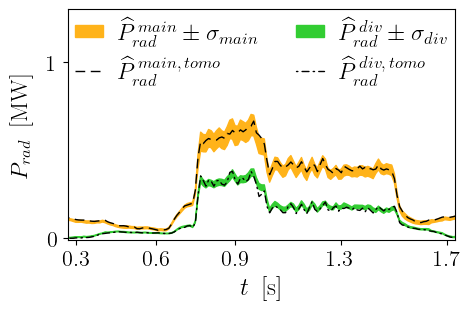

In [13]:
plt.figure(figsize=(5,3))


prads_roi = data[idx]["prads_roi"]
stds_prad_roi = data[idx]["stds_prad_roi"]
inversion_times = data[idx]["inversion_times"]
prads_roi_inversions = data[idx]["prads_roi_inversions"]

down_sampling_factor = 1
nb_stds = 1

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    'text.latex.preamble': r"""\usepackage{bm}""",
})

lower_bound = prads_roi[3,:] - nb_stds * stds_prad_roi[3, :]
upper_bound = prads_roi[3,:] + nb_stds * stds_prad_roi[3, :]
plt.fill_between(inversion_times[::down_sampling_factor], lower_bound[::down_sampling_factor], upper_bound[::down_sampling_factor], color=np.array([1, 0.7, 0.1]), label=r"$\widehat{P}_{rad}^{\,main}\pm\sigma_{main}$")
plt.plot(inversion_times[::down_sampling_factor], prads_roi_inversions[3,:].flatten()[::down_sampling_factor], 'k--', dashes=(7,4), linewidth=1, label=r"$\widehat{P}_{rad}^{\,main,\,tomo}$")

lower_bound = prads_roi[2,:] - nb_stds * stds_prad_roi[2, :]
upper_bound = prads_roi[2,:] + nb_stds * stds_prad_roi[2, :]
plt.fill_between(inversion_times[::down_sampling_factor], lower_bound[::down_sampling_factor], upper_bound[::down_sampling_factor], color=np.array([50/255, 205/255, 50/255]), label=r"$\widehat{P}_{rad}^{\,div}\pm\sigma_{div}$")
line, = plt.plot(inversion_times[::down_sampling_factor], prads_roi_inversions[2,:].flatten()[::down_sampling_factor], 'k-.', dashes=(7,4), linewidth=1, label=r"$\widehat{P}_{rad}^{\,div,\,tomo}$")
line.set_dashes([1, 3, 5, 3]) 
line.set_dash_capstyle('round')


plt.ylim([-1e4,1.3e6])
plt.xlim([0.27, 1.73])
plt.yticks([0,1e6], [r"$0$", r"$1$"], fontsize=16)
plt.xticks([0.3,0.6,0.9,1.3,1.7], [r"$0.3$", r"$0.6$", r"$0.9$", r"$1.3$", r"$1.7$"], fontsize=16)
plt.xlabel(r"$t\;\:[\mathrm{s}]$", fontsize=18)
plt.ylabel(r"$P_{rad}\;\:[\mathrm{MW}]$", fontsize=17, rotation=90, labelpad=10)
plt.legend(loc="upper left", frameon=False, ncols=2, handlelength=1.2, handleheight=0.4, fontsize=17, labelspacing=0.4, borderpad=0, borderaxespad=0.3, handletextpad=0.6, columnspacing=1.6)

#plt.savefig('figures/shot_85270_prad_div_and_main_chamber_study.eps', format='eps', bbox_inches="tight")


In [14]:
print("average mse")
print("tot,core,div,main: ", average_mse_errors[:,idx]/1e3)
print("average rel err")
print("tot,core,div,main: ", average_relative_errors[:,idx]*1e2)
print("average pearson r")
print("tot,core,div,main: ", avg_pearsons_r[:,idx])
print("average nb std")
print("tot,core,div,main: ", average_nb_stds_nosign[:,idx])

average mse
tot,core,div,main:  [ 4.9625604   5.52329391 11.96003548 13.30434285]
average rel err
tot,core,div,main:  [-1.75952332  1.01718928  5.10041113 -2.87901933]
average pearson r
tot,core,div,main:  [0.99993436 0.99724551 0.99470899 0.99856269]
average nb std
tot,core,div,main:  [0.41702095 0.67812741 0.98919863 0.48541824]


# Figure 4

## Upper single null

In [15]:
# select idx
idx = 17
print("Results for shot {}".format(all_shot_idxs[idx]))
shot=all_shot_idxs[idx]
rt_prad = RtPradROI(shot_nb=int(shot), bolo_good_channels=None, downsample=False)

Results for shot 86839


Text(0.5, 1.01, '$\\mathrm{upper\\;single\\;null}$')

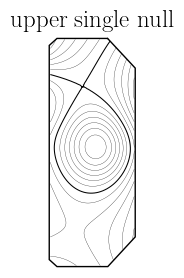

In [16]:
from matplotlib.colors import ListedColormap
newcolors = np.zeros((2,3))
newcolors[0,:] = np.array([1,1,1])
mask_color = np.array([1, 1, 1])
newcolors[1,:] = mask_color
newcmp = ListedColormap(newcolors)
tomo_plots.plot_profile(np.ones((120, 41)), figsize=(1.15, 3), tcv_plot_clip=True,
                    contour_image=rt_prad.fbte_eqs[12, :, :],
                    ax=None, colorbar=False, contour_color="k", vmin=0, vmax=None, aspect="auto",
                    levels=12, pad_cbar=0.2, cmap=newcmp)
plt.title(r"$\mathrm{upper\;single\;null}$", fontsize=18, y=1.01)
#plt.savefig('figures/usn_shot_'+str(shot)+'config_study.eps', format='eps', bbox_inches="tight")

Text(0.5, 1.02, '$\\mathrm{shot}\\;\\#86839\\mathrm{,\\;upper\\;single\\;null}$')

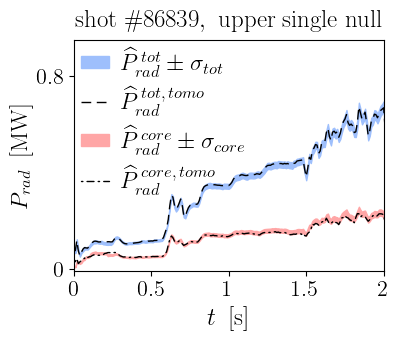

In [17]:
plt.figure(figsize=(4,3))

down_sampling_factor = 1
nb_stds = 1

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    'text.latex.preamble': r"""\usepackage{bm}""",
})


prads_roi = data[idx]["prads_roi"]
stds_prad_roi = data[idx]["stds_prad_roi"]
inversion_times = data[idx]["inversion_times"]
prads_roi_inversions = data[idx]["prads_roi_inversions"]

lower_bound = prads_roi[0,:] - nb_stds * stds_prad_roi[0, :]
upper_bound = prads_roi[0,:] + nb_stds * stds_prad_roi[0, :]
plt.fill_between(inversion_times, lower_bound, upper_bound, color=np.array([0.62,0.75,0.99]), label=r"$\widehat{P}_{rad}^{\,tot}\pm\sigma_{tot}$")
plt.plot(inversion_times, prads_roi_inversions[0,:].flatten(), 'k--', dashes=(7,4), linewidth=1, label=r"$\widehat{P}_{rad}^{\,tot,\,tomo}$")

lower_bound = prads_roi[1,:] - nb_stds * stds_prad_roi[1, :]
upper_bound = prads_roi[1,:] + nb_stds * stds_prad_roi[1, :]
plt.fill_between(inversion_times, lower_bound, upper_bound, color=np.array([1, 0.65, 0.65]), label=r"$\widehat{P}_{rad}^{\,core}\pm\sigma_{core}$")
line1, = plt.plot(inversion_times, prads_roi_inversions[1,:].flatten(), 'k-.', linewidth=1, label=r"$\widehat{P}_{rad}^{\,core,\,tomo}$")
line1.set_dashes([1, 3, 5, 3])  # 2pt line, 2pt break, pt line, 2pt break.
line1.set_dash_capstyle('round')


plt.xlim([0.0, 2])
plt.yticks([0,0.8e6], [r"$0$", r"$0.8$"], fontsize=16)
plt.ylim([-1e4,0.95e6])
plt.xticks([0, 0.5,1,1.5,2], [r"$0$",r"$0.5$", r"$1$", r"$1.5$", r"$2$"], fontsize=16)
plt.xlabel(r"$t\;\:[\mathrm{s}]$", fontsize=18)
plt.ylabel(r"$P_{rad}\;\:[\mathrm{MW}]$", fontsize=17, rotation=90, labelpad=2)
plt.legend(loc="upper left", frameon=False, ncols=1, handlelength=1.2, handleheight=0.4, fontsize=17, labelspacing=0.4, borderpad=0, borderaxespad=0.3, handletextpad=0.5, columnspacing=1.3)
plt.title(r"$\mathrm{shot}\;\#86839\mathrm{,\;upper\;single\;null}$", fontsize=18, y=1.02)

#plt.savefig('figures/usn_shot_'+str(shot)+'_prad_tot_and_core_title_study.eps', format='eps', bbox_inches="tight")


Text(0.5, 1.02, '$\\mathrm{shot}\\;\\#86839\\mathrm{,\\;upper\\;single\\;null}$')

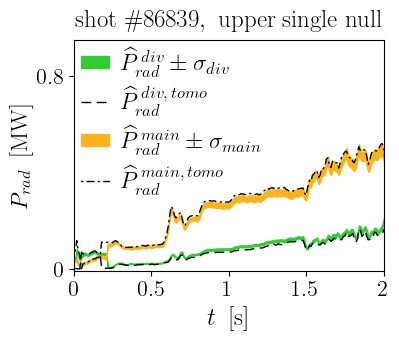

In [18]:
plt.figure(figsize=(4,3))

down_sampling_factor = 1
nb_stds = 1

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    'text.latex.preamble': r"""\usepackage{bm}""",
})


prads_roi = data[idx]["prads_roi"]
stds_prad_roi = data[idx]["stds_prad_roi"]
inversion_times = data[idx]["inversion_times"]
prads_roi_inversions = data[idx]["prads_roi_inversions"]

lower_bound = prads_roi[2,:] - nb_stds * stds_prad_roi[2, :]
upper_bound = prads_roi[2,:] + nb_stds * stds_prad_roi[2, :]
plt.fill_between(inversion_times, lower_bound, upper_bound, color=np.array([50/255, 205/255, 50/255]), label=r"$\widehat{P}_{rad}^{\,div}\pm\sigma_{div}$")
plt.plot(inversion_times, prads_roi_inversions[2,:].flatten(), 'k--', dashes=(7,4), linewidth=1, label=r"$\widehat{P}_{rad}^{\,div,\,tomo}$")

lower_bound = prads_roi[3,:] - nb_stds * stds_prad_roi[3, :]
upper_bound = prads_roi[3,:] + nb_stds * stds_prad_roi[3, :]
plt.fill_between(inversion_times, lower_bound, upper_bound, color=np.array([1, 0.7, 0.1]), label=r"$\widehat{P}_{rad}^{\,main}\pm\sigma_{main}$")
line1, = plt.plot(inversion_times, prads_roi_inversions[3,:].flatten(), 'k-.', linewidth=1, label=r"$\widehat{P}_{rad}^{\,main,\,tomo}$")
line1.set_dashes([1, 3, 5, 3])
line1.set_dash_capstyle('round')


plt.xlim([0.0, 2])
plt.yticks([0,0.8e6], [r"$0$", r"$0.8$"], fontsize=16)
plt.ylim([-1e4,0.95e6])
plt.xticks([0, 0.5,1,1.5,2], [r"$0$",r"$0.5$", r"$1$", r"$1.5$", r"$2$"], fontsize=16)
plt.xlabel(r"$t\;\:[\mathrm{s}]$", fontsize=18)
plt.ylabel(r"$P_{rad}\;\:[\mathrm{MW}]$", fontsize=17, rotation=90, labelpad=2)
plt.legend(loc="upper left", frameon=False, ncols=1, handlelength=1.2, handleheight=0.4, fontsize=17, labelspacing=0.4, borderpad=0, borderaxespad=0.3, handletextpad=0.5, columnspacing=1.3)
plt.title(r"$\mathrm{shot}\;\#86839\mathrm{,\;upper\;single\;null}$", fontsize=18, y=1.02)



In [19]:
print("average mse")
print("tot,core,div,main: ", average_mse_errors[:,idx]/1e3)
print("average rel err")
print("tot,core,div,main: ", average_relative_errors[:,idx]*1e2)
print("average pearson r")
print("tot,core,div,main: ", avg_pearsons_r[:,idx])
print("average nb std")
print("tot,core,div,main: ", average_nb_stds_nosign[:,idx])

average mse
tot,core,div,main:  [ 5.88669569  7.92153001 11.96619018 15.36906808]
average rel err
tot,core,div,main:  [-1.59360792  3.41095895 17.39084598 -5.07174504]
average pearson r
tot,core,div,main:  [0.99970356 0.99532704 0.99738867 0.9994594 ]
average nb std
tot,core,div,main:  [0.41629491 0.88304349 3.18362825 1.30393191]


## Negative triangularity

In [20]:
idx=26
shot = all_shot_idxs[idx]
rt_prad = RtPradROI(shot_nb=int(shot), bolo_good_channels=None, downsample=False)

Text(0.5, 1.01, '$\\mathrm{negative\\;triangularity}$')

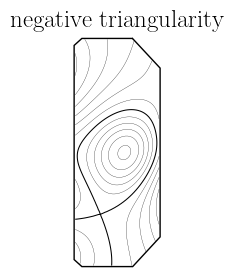

In [21]:
from matplotlib.colors import ListedColormap
newcolors = np.zeros((2,3))
newcolors[0,:] = np.array([1,1,1])
mask_color = np.array([1, 1, 1])
newcolors[1,:] = mask_color
newcmp = ListedColormap(newcolors)
tomo_plots.plot_profile(np.ones((120, 41)), figsize=(1.15, 3), tcv_plot_clip=True,
                    contour_image=rt_prad.fbte_eqs[22, :, :],
                    ax=None, colorbar=False, contour_color="k", vmin=0, vmax=None, aspect="auto",
                    levels=12, pad_cbar=0.2, cmap=newcmp)
plt.title(r"$\mathrm{negative\;triangularity}$", fontsize=18, y=1.01)
#plt.savefig('figures/nt_shot_'+str(shot)+'config_study.eps', format='eps', bbox_inches="tight")

Text(0.435, 1.02, '$\\mathrm{shot}\\;\\#86089\\mathrm{,\\;negative\\;triangularity}$')

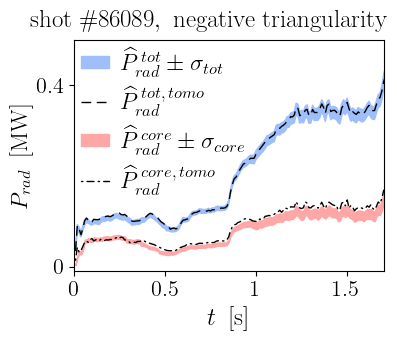

In [22]:
plt.figure(figsize=(4,3))

down_sampling_factor = 1
nb_stds = 1

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    'text.latex.preamble': r"""\usepackage{bm}""",
})


prads_roi = data[idx]["prads_roi"]
stds_prad_roi = data[idx]["stds_prad_roi"]
inversion_times = data[idx]["inversion_times"]
prads_roi_inversions = data[idx]["prads_roi_inversions"]

lower_bound = prads_roi[0,:] - nb_stds * stds_prad_roi[0, :]
upper_bound = prads_roi[0,:] + nb_stds * stds_prad_roi[0, :]
plt.fill_between(inversion_times, lower_bound, upper_bound, color=np.array([0.62,0.75,0.99]), label=r"$\widehat{P}_{rad}^{\,tot}\pm\sigma_{tot}$")
plt.plot(inversion_times, prads_roi_inversions[0,:].flatten(), 'k--', dashes=(7,4), linewidth=1, label=r"$\widehat{P}_{rad}^{\,tot,\,tomo}$")

lower_bound = prads_roi[1,:] - nb_stds * stds_prad_roi[1, :]
upper_bound = prads_roi[1,:] + nb_stds * stds_prad_roi[1, :]
plt.fill_between(inversion_times, lower_bound, upper_bound, color=np.array([1, 0.65, 0.65]), label=r"$\widehat{P}_{rad}^{\,core}\pm\sigma_{core}$")
line1, = plt.plot(inversion_times, prads_roi_inversions[1,:].flatten(), 'k-.', linewidth=1, label=r"$\widehat{P}_{rad}^{\,core,\,tomo}$")
line1.set_dashes([1, 3, 5, 3]) 
line1.set_dash_capstyle('round')


plt.xlim([0.0, 1.7])
plt.yticks([0,0.4e6], [r"$0$", r"$0.4$"], fontsize=16)
plt.ylim([-1e4,0.5e6])
plt.xticks([0, 0.5,1,1.5], [r"$0$",r"$0.5$", r"$1$", r"$1.5$"], fontsize=16)
plt.xlabel(r"$t\;\:[\mathrm{s}]$", fontsize=18)
plt.ylabel(r"$P_{rad}\;\:[\mathrm{MW}]$", fontsize=17, rotation=90, labelpad=2)
plt.legend(loc="upper left", frameon=False, ncols=1, handlelength=1.2, handleheight=0.4, fontsize=17, labelspacing=0.4, borderpad=0, borderaxespad=0.3, handletextpad=0.5, columnspacing=1.3)
plt.title(r"$\mathrm{shot}\;\#86089\mathrm{,\;negative\;triangularity}$", fontsize=18, y=1.02, x=0.435)

#plt.savefig('figures/nt_shot_'+str(shot)+'_prad_tot_and_core_title_study.eps', format='eps', bbox_inches="tight")


Text(0.435, 1.02, '$\\mathrm{shot}\\;\\#86089\\mathrm{,\\;negative\\;triangularity}$')

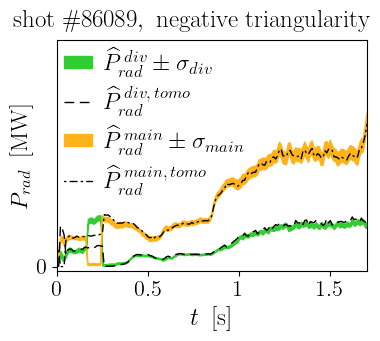

In [23]:
plt.figure(figsize=(4,3))

down_sampling_factor = 1
nb_stds = 1

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    'text.latex.preamble': r"""\usepackage{bm}""",
})


prads_roi = data[idx]["prads_roi"]
stds_prad_roi = data[idx]["stds_prad_roi"]
inversion_times = data[idx]["inversion_times"]
prads_roi_inversions = data[idx]["prads_roi_inversions"]

lower_bound = prads_roi[2,:] - nb_stds * stds_prad_roi[2, :]
upper_bound = prads_roi[2,:] + nb_stds * stds_prad_roi[2, :]
plt.fill_between(inversion_times, lower_bound, upper_bound, color=np.array([50/255, 205/255, 50/255]), label=r"$\widehat{P}_{rad}^{\,div}\pm\sigma_{div}$")
plt.plot(inversion_times, prads_roi_inversions[2,:].flatten(), 'k--', dashes=(7,4), linewidth=1, label=r"$\widehat{P}_{rad}^{\,div,\,tomo}$")

lower_bound = prads_roi[3,:] - nb_stds * stds_prad_roi[3, :]
upper_bound = prads_roi[3,:] + nb_stds * stds_prad_roi[3, :]
plt.fill_between(inversion_times, lower_bound, upper_bound, color=np.array([1, 0.7, 0.1]), label=r"$\widehat{P}_{rad}^{\,main}\pm\sigma_{main}$")
line1, = plt.plot(inversion_times, prads_roi_inversions[3,:].flatten(), 'k-.', linewidth=1, label=r"$\widehat{P}_{rad}^{\,main,\,tomo}$")
line1.set_dashes([1, 3, 5, 3])
line1.set_dash_capstyle('round')


plt.yticks([0,0.8e6], [r"$0$", r"$0.8$"], fontsize=16)
plt.ylim([-1e4,0.5e6])
plt.xticks([0, 0.5,1,1.5,2], [r"$0$",r"$0.5$", r"$1$", r"$1.5$", r"$2$"], fontsize=16)
plt.xlim([0.0, 1.7])
plt.xlabel(r"$t\;\:[\mathrm{s}]$", fontsize=18)
plt.ylabel(r"$P_{rad}\;\:[\mathrm{MW}]$", fontsize=17, rotation=90, labelpad=2)
plt.legend(loc="upper left", frameon=False, ncols=1, handlelength=1.2, handleheight=0.4, fontsize=17, labelspacing=0.4, borderpad=0, borderaxespad=0.3, handletextpad=0.5, columnspacing=1.3)
plt.title(r"$\mathrm{shot}\;\#86089\mathrm{,\;negative\;triangularity}$", fontsize=18, y=1.02, x=0.435)



In [24]:
print("average mse")
print("tot,core,div,main: ", average_mse_errors[:,idx]/1e3)
print("average rel err")
print("tot,core,div,main: ", average_relative_errors[:,idx]*1e2)
print("average pearson r")
print("tot,core,div,main: ", avg_pearsons_r[:,idx])
print("average nb std")
print("tot,core,div,main: ", average_nb_stds_nosign[:,idx])

average mse
tot,core,div,main:  [ 4.7215385  11.29195215  4.38454054  4.26787187]
average rel err
tot,core,div,main:  [-1.56444036 -9.25183472 -2.52605189 -0.18686505]
average pearson r
tot,core,div,main:  [0.99959996 0.9939456  0.9968198  0.99921299]
average nb std
tot,core,div,main:  [0.46604375 1.54532427 0.93463419 0.3595722 ]


## X-point target

In [25]:
idx=34
shot = all_shot_idxs[idx]
rt_prad = RtPradROI(shot_nb=int(shot), bolo_good_channels=None, downsample=False)

Text(0.5, 1.01, '$\\mathrm{X}$-$\\mathrm{point\\;target}$')

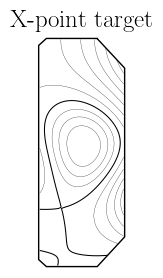

In [26]:
from matplotlib.colors import ListedColormap
newcolors = np.zeros((2,3))
newcolors[0,:] = np.array([1,1,1])
mask_color = np.array([1, 1, 1])
newcolors[1,:] = mask_color
newcmp = ListedColormap(newcolors)
tomo_plots.plot_profile(np.ones((120, 41)), figsize=(1.15, 3), tcv_plot_clip=True,
                    contour_image=rt_prad.fbte_eqs[20, :, :],
                    ax=None, colorbar=False, contour_color="k", vmin=0, vmax=None, aspect="auto",
                    levels=12, pad_cbar=0.2, cmap=newcmp)
plt.title(r"$\mathrm{X}$-$\mathrm{point\;target}$", fontsize=18, y=1.01)
#plt.savefig('figures/xpt_shot_'+str(shot)+'_config_study.eps', format='eps', bbox_inches="tight")

Text(0.5, 1.02, '$\\mathrm{shot}\\;\\#85357,\\;\\mathrm{X}$-$\\mathrm{point\\;target}$')

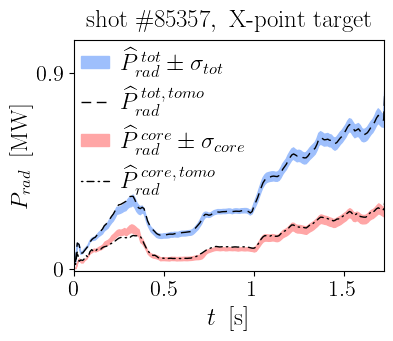

In [27]:
plt.figure(figsize=(4,3))

down_sampling_factor = 1
nb_stds = 1

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    'text.latex.preamble': r"""\usepackage{bm}""",
})


prads_roi = data[idx]["prads_roi"]
stds_prad_roi = data[idx]["stds_prad_roi"]
inversion_times = data[idx]["inversion_times"]
prads_roi_inversions = data[idx]["prads_roi_inversions"]

lower_bound = prads_roi[0,:] - nb_stds * stds_prad_roi[0, :]
upper_bound = prads_roi[0,:] + nb_stds * stds_prad_roi[0, :]
plt.fill_between(inversion_times, lower_bound, upper_bound, color=np.array([0.62,0.75,0.99]), label=r"$\widehat{P}_{rad}^{\,tot}\pm\sigma_{tot}$")
plt.plot(inversion_times, prads_roi_inversions[0,:].flatten(), 'k--', dashes=(7,4), linewidth=1, label=r"$\widehat{P}_{rad}^{\,tot,\,tomo}$")

lower_bound = prads_roi[1,:] - nb_stds * stds_prad_roi[1, :]
upper_bound = prads_roi[1,:] + nb_stds * stds_prad_roi[1, :]
plt.fill_between(inversion_times, lower_bound, upper_bound, color=np.array([1, 0.65, 0.65]), label=r"$\widehat{P}_{rad}^{\,core}\pm\sigma_{core}$")
line1, = plt.plot(inversion_times, prads_roi_inversions[1,:].flatten(), 'k-.', linewidth=1, label=r"$\widehat{P}_{rad}^{\,core,\,tomo}$")
line1.set_dashes([1, 3, 5, 3])  
line1.set_dash_capstyle('round')


plt.xlim([0.0, 1.72])
plt.yticks([0,0.9e6], [r"$0$", r"$0.9$"], fontsize=16)
plt.ylim([-1e4,1.05e6])
plt.xticks([0, 0.5,1,1.5], [r"$0$",r"$0.5$", r"$1$", r"$1.5$"], fontsize=16)
plt.xlabel(r"$t\;\:[\mathrm{s}]$", fontsize=18)
plt.ylabel(r"$P_{rad}\;\:[\mathrm{MW}]$", fontsize=17, rotation=90, labelpad=2)
plt.legend(loc="upper left", frameon=False, ncols=1, handlelength=1.2, handleheight=0.4, fontsize=17, labelspacing=0.4, borderpad=0, borderaxespad=0.3, handletextpad=0.5, columnspacing=1.3)
plt.title(r"$\mathrm{shot}\;\#85357,\;\mathrm{X}$-$\mathrm{point\;target}$", fontsize=18, y=1.02)

#plt.savefig('figures/xpt_shot_'+str(shot)+'_prad_tot_and_core_title_study.eps', format='eps', bbox_inches="tight")


Text(0.5, 1.02, '$\\mathrm{shot}\\;\\#85357,\\;\\mathrm{X}$-$\\mathrm{point\\;target}$')

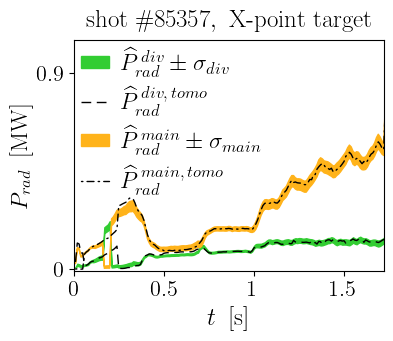

In [28]:
plt.figure(figsize=(4,3))

down_sampling_factor = 1
nb_stds = 1

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    'text.latex.preamble': r"""\usepackage{bm}""",
})


prads_roi = data[idx]["prads_roi"]
stds_prad_roi = data[idx]["stds_prad_roi"]
inversion_times = data[idx]["inversion_times"]
prads_roi_inversions = data[idx]["prads_roi_inversions"]

lower_bound = prads_roi[2,:] - nb_stds * stds_prad_roi[2, :]
upper_bound = prads_roi[2,:] + nb_stds * stds_prad_roi[2, :]
plt.fill_between(inversion_times, lower_bound, upper_bound, color=np.array([50/255, 205/255, 50/255]), label=r"$\widehat{P}_{rad}^{\,div}\pm\sigma_{div}$")
plt.plot(inversion_times, prads_roi_inversions[2,:].flatten(), 'k--', dashes=(7,4), linewidth=1, label=r"$\widehat{P}_{rad}^{\,div,\,tomo}$")

lower_bound = prads_roi[3,:] - nb_stds * stds_prad_roi[3, :]
upper_bound = prads_roi[3,:] + nb_stds * stds_prad_roi[3, :]
plt.fill_between(inversion_times, lower_bound, upper_bound, color=np.array([1, 0.7, 0.1]), label=r"$\widehat{P}_{rad}^{\,main}\pm\sigma_{main}$")
line1, = plt.plot(inversion_times, prads_roi_inversions[3,:].flatten(), 'k-.', linewidth=1, label=r"$\widehat{P}_{rad}^{\,main,\,tomo}$")
line1.set_dashes([1, 3, 5, 3])
line1.set_dash_capstyle('round')

plt.ylim([-1e4,1.05e6])
plt.yticks([0,0.9e6], [r"$0$", r"$0.9$"], fontsize=16)
plt.xticks([0, 0.5,1,1.5,2], [r"$0$",r"$0.5$", r"$1$", r"$1.5$", r"$2$"], fontsize=16)
plt.xlim([0.0, 1.72])
plt.xlabel(r"$t\;\:[\mathrm{s}]$", fontsize=18)
plt.ylabel(r"$P_{rad}\;\:[\mathrm{MW}]$", fontsize=17, rotation=90, labelpad=2)
plt.legend(loc="upper left", frameon=False, ncols=1, handlelength=1.2, handleheight=0.4, fontsize=17, labelspacing=0.4, borderpad=0, borderaxespad=0.3, handletextpad=0.5, columnspacing=1.3)
plt.title(r"$\mathrm{shot}\;\#85357,\;\mathrm{X}$-$\mathrm{point\;target}$", fontsize=18, y=1.02)



In [29]:
print("average mse")
print("tot,core,div,main: ", average_mse_errors[:,idx]/1e3)
print("average rel err")
print("tot,core,div,main: ", average_relative_errors[:,idx]*1e2)
print("average pearson r")
print("tot,core,div,main: ", avg_pearsons_r[:,idx])
print("average nb std")
print("tot,core,div,main: ", average_nb_stds_nosign[:,idx])

average mse
tot,core,div,main:  [ 7.75928548 11.52368687  6.36785934  6.07954372]
average rel err
tot,core,div,main:  [-1.68579319 -1.74086954 -0.05127594 -0.18437149]
average pearson r
tot,core,div,main:  [0.99938966 0.98668807 0.9758604  0.99930369]
average nb std
tot,core,div,main:  [0.34693038 0.83797214 0.94301419 0.29775177]


## long-legged

In [30]:
idx=40
shot = all_shot_idxs[idx]
rt_prad = RtPradROI(shot_nb=int(shot), bolo_good_channels=None, downsample=False)

Text(0.5, 1.01, '$\\mathrm{long}$-$\\mathrm{legged}$')

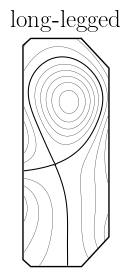

In [31]:
from matplotlib.colors import ListedColormap
newcolors = np.zeros((2,3))
newcolors[0,:] = np.array([1,1,1])
mask_color = np.array([1, 1, 1])
newcolors[1,:] = mask_color
newcmp = ListedColormap(newcolors)
tomo_plots.plot_profile(np.ones((120, 41)), figsize=(1.15, 3), tcv_plot_clip=True,
                    contour_image=rt_prad.fbte_eqs[20, :, :],
                    ax=None, colorbar=False, contour_color="k", vmin=0, vmax=None, aspect="auto",
                    levels=12, pad_cbar=0.2, cmap=newcmp)
plt.title(r"$\mathrm{long}$-$\mathrm{legged}$", fontsize=18, y=1.01)
#plt.savefig('figures/ll_shot_'+str(shot)+'_config_study.eps', format='eps', bbox_inches="tight")

Text(0.5, 1.02, '$\\mathrm{shot}\\;\\#85166,\\;\\mathrm{long}$-$\\mathrm{legged}$')

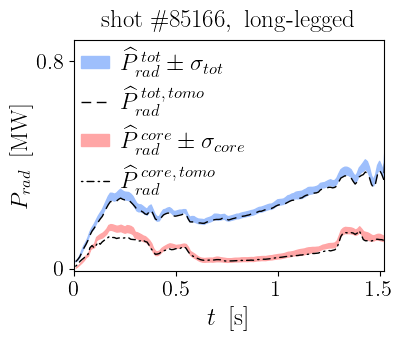

In [32]:
plt.figure(figsize=(4,3))

down_sampling_factor = 1
nb_stds = 1

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    'text.latex.preamble': r"""\usepackage{bm}""",
})


prads_roi = data[idx]["prads_roi"]
stds_prad_roi = data[idx]["stds_prad_roi"]
inversion_times = data[idx]["inversion_times"]
prads_roi_inversions = data[idx]["prads_roi_inversions"]

lower_bound = prads_roi[0,:] - nb_stds * stds_prad_roi[0, :]
upper_bound = prads_roi[0,:] + nb_stds * stds_prad_roi[0, :]
plt.fill_between(inversion_times, lower_bound, upper_bound, color=np.array([0.62,0.75,0.99]), label=r"$\widehat{P}_{rad}^{\,tot}\pm\sigma_{tot}$")
plt.plot(inversion_times, prads_roi_inversions[0,:].flatten(), 'k--', dashes=(7,4), linewidth=1, label=r"$\widehat{P}_{rad}^{\,tot,\,tomo}$")

lower_bound = prads_roi[1,:] - nb_stds * stds_prad_roi[1, :]
upper_bound = prads_roi[1,:] + nb_stds * stds_prad_roi[1, :]
plt.fill_between(inversion_times, lower_bound, upper_bound, color=np.array([1, 0.65, 0.65]), label=r"$\widehat{P}_{rad}^{\,core}\pm\sigma_{core}$")
line1, = plt.plot(inversion_times, prads_roi_inversions[1,:].flatten(), 'k-.', linewidth=1, label=r"$\widehat{P}_{rad}^{\,core,\,tomo}$")
line1.set_dashes([1, 3, 5, 3]) 
line1.set_dash_capstyle('round')


plt.xlim([0.0, 1.52])
plt.yticks([0,0.8e6], [r"$0$", r"$0.8$"], fontsize=16)
plt.ylim([-1e4,0.88e6])
plt.xticks([0, 0.5,1,1.5], [r"$0$",r"$0.5$", r"$1$", r"$1.5$"], fontsize=16)
plt.xlabel(r"$t\;\:[\mathrm{s}]$", fontsize=18)
plt.ylabel(r"$P_{rad}\;\:[\mathrm{MW}]$", fontsize=17, rotation=90, labelpad=2)
plt.legend(loc="upper left", frameon=False, ncols=1, handlelength=1.2, handleheight=0.4, fontsize=17, labelspacing=0.4, borderpad=0, borderaxespad=0.3, handletextpad=0.5, columnspacing=1.3)
plt.title(r"$\mathrm{shot}\;\#85166,\;\mathrm{long}$-$\mathrm{legged}$", fontsize=18, y=1.02)

#plt.savefig('figures/ll_shot_'+str(shot)+'_prad_tot_and_core_title_study.eps', format='eps', bbox_inches="tight")


Text(0.5, 1.02, '$\\mathrm{shot}\\;\\#85166,\\;\\mathrm{long}$-$\\mathrm{legged}$')

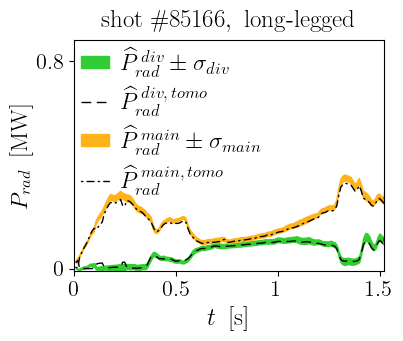

In [33]:
plt.figure(figsize=(4,3))

down_sampling_factor = 1
nb_stds = 1

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    'text.latex.preamble': r"""\usepackage{bm}""",
})


prads_roi = data[idx]["prads_roi"]
stds_prad_roi = data[idx]["stds_prad_roi"]
inversion_times = data[idx]["inversion_times"]
prads_roi_inversions = data[idx]["prads_roi_inversions"]

lower_bound = prads_roi[2,:] - nb_stds * stds_prad_roi[2, :]
upper_bound = prads_roi[2,:] + nb_stds * stds_prad_roi[2, :]
plt.fill_between(inversion_times, lower_bound, upper_bound, color=np.array([50/255, 205/255, 50/255]), label=r"$\widehat{P}_{rad}^{\,div}\pm\sigma_{div}$")
plt.plot(inversion_times, prads_roi_inversions[2,:].flatten(), 'k--', dashes=(7,4), linewidth=1, label=r"$\widehat{P}_{rad}^{\,div,\,tomo}$")

lower_bound = prads_roi[3,:] - nb_stds * stds_prad_roi[3, :]
upper_bound = prads_roi[3,:] + nb_stds * stds_prad_roi[3, :]
plt.fill_between(inversion_times, lower_bound, upper_bound, color=np.array([1, 0.7, 0.1]), label=r"$\widehat{P}_{rad}^{\,main}\pm\sigma_{main}$")
line1, = plt.plot(inversion_times, prads_roi_inversions[3,:].flatten(), 'k-.', linewidth=1, label=r"$\widehat{P}_{rad}^{\,main,\,tomo}$")
line1.set_dashes([1, 3, 5, 3])
line1.set_dash_capstyle('round')

plt.xlim([0.0, 1.52])
plt.yticks([0,0.8e6], [r"$0$", r"$0.8$"], fontsize=16)
plt.ylim([-1e4,0.88e6])
plt.xticks([0, 0.5,1,1.5], [r"$0$",r"$0.5$", r"$1$", r"$1.5$"], fontsize=16)
plt.xlabel(r"$t\;\:[\mathrm{s}]$", fontsize=18)
plt.ylabel(r"$P_{rad}\;\:[\mathrm{MW}]$", fontsize=17, rotation=90, labelpad=2)
plt.legend(loc="upper left", frameon=False, ncols=1, handlelength=1.2, handleheight=0.4, fontsize=17, labelspacing=0.4, borderpad=0, borderaxespad=0.3, handletextpad=0.5, columnspacing=1.3)
plt.title(r"$\mathrm{shot}\;\#85166,\;\mathrm{long}$-$\mathrm{legged}$", fontsize=18, y=1.02)



In [34]:
print("average mse")
print("tot,core,div,main: ", average_mse_errors[:,idx]/1e3)
print("average rel err")
print("tot,core,div,main: ", average_relative_errors[:,idx]*1e2)
print("average pearson r")
print("tot,core,div,main: ", avg_pearsons_r[:,idx])
print("average nb std")
print("tot,core,div,main: ", average_nb_stds_nosign[:,idx])

average mse
tot,core,div,main:  [12.89825211 15.64326083  4.72301994  8.98766679]
average rel err
tot,core,div,main:  [ 4.60578655 15.8407461   3.92925588  3.81721392]
average pearson r
tot,core,div,main:  [0.99871239 0.98081674 0.9968897  0.99950053]
average nb std
tot,core,div,main:  [1.04418235 1.31433476 0.42044178 0.85980562]


# Table 1: results of campaign study

In [35]:
print("Using always all channels excluded [70,2,6,118]")
# exclude shots 22 and 41, there are nan measurements. in both cases it's channel 0, the shots are close in time.
# Strategies S2-S3-S4 would have correctly excluded the channel from the computations
idxs_avg=np.arange(0,50)
# delete two cases with NaNs
idxs_avg=np.delete(idxs_avg,np.where(idxs_avg==22))
idxs_avg=np.delete(idxs_avg,np.where(idxs_avg==41))
print("avg rel err tot: {} +- {}".format(np.mean(average_relative_errors_basic[0,idxs_avg]), np.std(average_relative_errors_basic[0,idxs_avg])))
print("avg rel err core: {} +- {}".format(np.mean(average_relative_errors_basic[1,idxs_avg]), np.std(average_relative_errors_basic[1,idxs_avg])))
print("avg rel err div: {} +- {}".format(np.mean(average_relative_errors_basic[2,idxs_avg]), np.std(average_relative_errors_basic[2,idxs_avg])))
print("avg rel err main: {} +- {}".format(np.mean(average_relative_errors_basic[3,idxs_avg]), np.std(average_relative_errors_basic[3,idxs_avg])))
print("\navg mse tot: {} +- {}".format(np.mean(average_mse_errors_basic[0,idxs_avg]), np.std(average_mse_errors_basic[0,idxs_avg])))
print("avg mse core: {} +- {}".format(np.mean(average_mse_errors_basic[1,idxs_avg]), np.std(average_mse_errors_basic[1,idxs_avg])))
print("avg mse div: {} +- {}".format(np.mean(average_mse_errors_basic[2,idxs_avg]), np.std(average_mse_errors_basic[2,idxs_avg])))
print("avg mse main: {} +- {}".format(np.mean(average_mse_errors_basic[3,idxs_avg]), np.std(average_mse_errors_basic[3,idxs_avg])))
print("\navg R tot: {} +- {}".format(np.mean(avg_pearsons_r_basic[0,idxs_avg]), np.std(avg_pearsons_r_basic[0,idxs_avg])))
print("avg R core: {} +- {}".format(np.mean(avg_pearsons_r_basic[1,idxs_avg]), np.std(avg_pearsons_r_basic[1,idxs_avg])))
print("avg R div: {} +- {}".format(np.mean(avg_pearsons_r_basic[2,idxs_avg]), np.std(avg_pearsons_r_basic[2,idxs_avg])))
print("avg R main: {} +- {}".format(np.mean(avg_pearsons_r_basic[3,idxs_avg]), np.std(avg_pearsons_r_basic[3,idxs_avg])))
print("\nabs avg nb stds tot: {} +- {}".format(np.mean(average_nb_stds_basic_nosign[0,idxs_avg]), np.std(average_nb_stds_basic_nosign[0,idxs_avg])))
print("abs avg nb stds core: {} +- {}".format(np.mean(average_nb_stds_basic_nosign[1,idxs_avg]), np.std(average_nb_stds_basic_nosign[1,idxs_avg])))
print("abs avg nb stds div: {} +- {}".format(np.mean(average_nb_stds_basic_nosign[2,idxs_avg]), np.std(average_nb_stds_basic_nosign[2,idxs_avg])))
print("abs avg nb stds main: {} +- {}".format(np.mean(average_nb_stds_basic_nosign[3,idxs_avg]), np.std(average_nb_stds_basic_nosign[3,idxs_avg])))

Using always all channels excluded [70,2,6,118]
avg rel err tot: 0.37889340221326334 +- 0.5620909892575524
avg rel err core: 0.05464192477928113 +- 0.8015917392330747
avg rel err div: 0.10128918720125718 +- 0.8774279902045714
avg rel err main: 0.46059791721449966 +- 0.6768390315545341

avg mse tot: 254487.32807931816 +- 453846.56721273577
avg mse core: 126073.27261545247 +- 299438.96994765487
avg mse div: 67893.7185880259 +- 89324.73803766097
avg mse main: 257386.54787625326 +- 438458.9338143549

avg R tot: 0.7762816189452443 +- 0.2802140352473827
avg R core: 0.7407090131354644 +- 0.34454558329195967
avg R div: 0.6545905789153502 +- 0.32916322948975063
avg R main: 0.7618345539233076 +- 0.29088108777395344

abs avg nb stds tot: 3.1921265199316076 +- 4.6157737838925055
abs avg nb stds core: 2.6886531966271847 +- 4.954675477034625
abs avg nb stds div: 2.126272051247203 +- 1.2925543500089303
abs avg nb stds main: 3.061036593780218 +- 4.487344492806764


In [36]:
print("Using only good channels")
print("avg rel err tot: {} +- {}".format(np.mean(average_relative_errors[0,:]), np.std(average_relative_errors[0,:])))
print("avg rel err core: {} +- {}".format(np.mean(average_relative_errors[1,:]), np.std(average_relative_errors[1,:])))
print("avg rel err div: {} +- {}".format(np.mean(average_relative_errors[2,:]), np.std(average_relative_errors[2,:])))
print("avg rel err main: {} +- {}".format(np.mean(average_relative_errors[3,:]), np.std(average_relative_errors[3,:])))
print("\navg mse tot: {} +- {}".format(np.mean(average_mse_errors[0,:]), np.std(average_mse_errors[0,:])))
print("avg mse core: {} +- {}".format(np.mean(average_mse_errors[1,:]), np.std(average_mse_errors[1,:])))
print("avg mse div: {} +- {}".format(np.mean(average_mse_errors[2,:]), np.std(average_mse_errors[2,:])))
print("avg mse main: {} +- {}".format(np.mean(average_mse_errors[3,:]), np.std(average_mse_errors[3,:])))
print("\navg R tot: {} +- {}".format(np.mean(avg_pearsons_r[0,:]), np.std(avg_pearsons_r[0,:])))
print("avg R core: {} +- {}".format(np.mean(avg_pearsons_r[1,:]), np.std(avg_pearsons_r[1,:])))
print("avg R div: {} +- {}".format(np.mean(avg_pearsons_r[2,:]), np.std(avg_pearsons_r[2,:])))
print("avg R main: {} +- {}".format(np.mean(avg_pearsons_r[3,:]), np.std(avg_pearsons_r[3,:])))
print("\nabs avg nb stds tot: {} +- {}".format(np.mean(average_nb_stds_nosign[0,:]), np.std(average_nb_stds_nosign[0,:])))
print("abs avg nb stds core: {} +- {}".format(np.mean(average_nb_stds_nosign[1,:]), np.std(average_nb_stds_nosign[1,:])))
print("abs avg nb stds div: {} +- {}".format(np.mean(average_nb_stds_nosign[2,:]), np.std(average_nb_stds_nosign[2,:])))
print("abs avg nb stds main: {} +- {}".format(np.mean(average_nb_stds_nosign[3,:]), np.std(average_nb_stds_nosign[3,:])))

Using only good channels
avg rel err tot: -0.0008997428537159516 +- 0.030094881619331406
avg rel err core: 0.060317476527431746 +- 0.12563924208060032
avg rel err div: 0.07110874638589235 +- 0.08551431704489712
avg rel err main: -0.013496603691756133 +- 0.04460826258814759

avg mse tot: 10436.594966236085 +- 7782.217707715584
avg mse core: 12606.564556882482 +- 5131.640416667772
avg mse div: 10354.23028289468 +- 12473.659415311635
avg mse main: 10790.776873624774 +- 8158.434612046448

avg R tot: 0.9924598257692123 +- 0.02221341188338991
avg R core: 0.9742255308174649 +- 0.025397000542464004
avg R div: 0.9748223935811182 +- 0.05129227388491732
avg R main: 0.9936708307685894 +- 0.01120083833233848

abs avg nb stds tot: 0.7113889144709318 +- 0.3895841023818456
abs avg nb stds core: 1.2186825717949898 +- 0.4197561939251978
abs avg nb stds div: 1.4677529595671315 +- 1.1651517782517153
abs avg nb stds main: 0.7449557154896077 +- 0.5103786353824372


In [37]:
print("Using good channels from previous shot")
print("\navg rel err tot: {} +- {}".format(np.mean(average_relative_errors_prev[0,:]), np.std(average_relative_errors_prev[0,:])))
print("avg rel err core: {} +- {}".format(np.mean(average_relative_errors_prev[1,:]), np.std(average_relative_errors_prev[1,:])))
print("avg rel err div: {} +- {}".format(np.mean(average_relative_errors_prev[2,:]), np.std(average_relative_errors_prev[2,:])))
print("avg rel err main: {} +- {}".format(np.mean(average_relative_errors_prev[3,:]), np.std(average_relative_errors_prev[3,:])))
print("\navg mse tot: {} +- {}".format(np.mean(average_mse_errors_prev[0,:]), np.std(average_mse_errors_prev[0,:])))
print("avg mse core: {} +- {}".format(np.mean(average_mse_errors_prev[1,:]), np.std(average_mse_errors_prev[1,:])))
print("avg mse div: {} +- {}".format(np.mean(average_mse_errors_prev[2,:]), np.std(average_mse_errors_prev[2,:])))
print("avg mse main: {} +- {}".format(np.mean(average_mse_errors_prev[3,:]), np.std(average_mse_errors_prev[3,:])))
print("\navg R tot: {} +- {}".format(np.mean(avg_pearsons_r_prev[0,:]), np.std(avg_pearsons_r_prev[0,:])))
print("avg R core: {} +- {}".format(np.mean(avg_pearsons_r_prev[1,:]), np.std(avg_pearsons_r_prev[1,:])))
print("avg R div: {} +- {}".format(np.mean(avg_pearsons_r_prev[2,:]), np.std(avg_pearsons_r_prev[2,:])))
print("avg R main: {} +- {}".format(np.mean(avg_pearsons_r_prev[3,:]), np.std(avg_pearsons_r_prev[3,:])))
print("\nabs avg nb stds tot: {} +- {}".format(np.mean(average_nb_stds_prev_nosign[0,:]), np.std(average_nb_stds_prev_nosign[0,:])))
print("abs avg nb stds core: {} +- {}".format(np.mean(average_nb_stds_prev_nosign[1,:]), np.std(average_nb_stds_prev_nosign[1,:])))
print("abs avg nb stds div: {} +- {}".format(np.mean(average_nb_stds_prev_nosign[2,:]), np.std(average_nb_stds_prev_nosign[2,:])))
print("abs avg nb stds main: {} +- {}".format(np.mean(average_nb_stds_prev_nosign[3,:]), np.std(average_nb_stds_prev_nosign[3,:])))

Using good channels from previous shot

avg rel err tot: -0.0019105232351895054 +- 0.03100290341083117
avg rel err core: 0.05907204709073708 +- 0.12280355788030718
avg rel err div: 0.06804693595491232 +- 0.09284858335271291
avg rel err main: -0.012680883064946954 +- 0.045842113973095025

avg mse tot: 10576.425526315019 +- 7859.919711428676
avg mse core: 12557.374239597319 +- 5101.881544429101
avg mse div: 10627.38635032359 +- 12582.540531348146
avg mse main: 10868.437822255699 +- 8153.246605722174

avg R tot: 0.9921759724162763 +- 0.022308180502428554
avg R core: 0.9742819285230145 +- 0.02542718882869034
avg R div: 0.9695059826700069 +- 0.06437766739834949
avg R main: 0.9936624763061921 +- 0.011194897485380842

abs avg nb stds tot: 0.7292982589696461 +- 0.39587360426687884
abs avg nb stds core: 1.2270703237672393 +- 0.41814413599828293
abs avg nb stds div: 1.5082648846185542 +- 1.1653050866960808
abs avg nb stds main: 0.7607758434574629 +- 0.5090481515278127


In [38]:
print("Using good channels from previous shot and removing channels known to be unstable")
print("\navg rel err tot: {} +- {}".format(np.mean(average_relative_errors_prev_stable[0,:]), np.std(average_relative_errors_prev_stable[0,:])))
print("avg rel err core: {} +- {}".format(np.mean(average_relative_errors_prev_stable[1,:]), np.std(average_relative_errors_prev_stable[1,:])))
print("avg rel err div: {} +- {}".format(np.mean(average_relative_errors_prev_stable[2,:]), np.std(average_relative_errors_prev_stable[2,:])))
print("avg rel err main: {} +- {}".format(np.mean(average_relative_errors_prev_stable[3,:]), np.std(average_relative_errors_prev_stable[3,:])))
print("\navg mse tot: {} +- {}".format(np.mean(average_mse_errors_prev_stable[0,:]), np.std(average_mse_errors_prev_stable[0,:])))
print("avg mse core: {} +- {}".format(np.mean(average_mse_errors_prev_stable[1,:]), np.std(average_mse_errors_prev_stable[1,:])))
print("avg mse div: {} +- {}".format(np.mean(average_mse_errors_prev_stable[2,:]), np.std(average_mse_errors_prev_stable[2,:])))
print("avg mse main: {} +- {}".format(np.mean(average_mse_errors_prev_stable[3,:]), np.std(average_mse_errors_prev_stable[3,:])))
print("\navg R tot: {} +- {}".format(np.mean(avg_pearsons_r_prev_stable[0,:]), np.std(avg_pearsons_r_prev_stable[0,:])))
print("avg R core: {} +- {}".format(np.mean(avg_pearsons_r_prev_stable[1,:]), np.std(avg_pearsons_r_prev_stable[1,:])))
print("avg R div: {} +- {}".format(np.mean(avg_pearsons_r_prev_stable[2,:]), np.std(avg_pearsons_r_prev_stable[2,:])))
print("avg R main: {} +- {}".format(np.mean(avg_pearsons_r_prev_stable[3,:]), np.std(avg_pearsons_r_prev_stable[3,:])))
print("\nabs avg nb stds tot: {} +- {}".format(np.mean(average_nb_stds_prev_stable_nosign[0,:]), np.std(average_nb_stds_prev_stable_nosign[0,:])))
print("abs avg nb stds core: {} +- {}".format(np.mean(average_nb_stds_prev_stable_nosign[1,:]), np.std(average_nb_stds_prev_stable_nosign[1,:])))
print("abs avg nb stds div: {} +- {}".format(np.mean(average_nb_stds_prev_stable_nosign[2,:]), np.std(average_nb_stds_prev_stable_nosign[2,:])))
print("abs avg nb stds main: {} +- {}".format(np.mean(average_nb_stds_prev_stable_nosign[3,:]), np.std(average_nb_stds_prev_stable_nosign[3,:])))

Using good channels from previous shot and removing channels known to be unstable

avg rel err tot: 0.0003730530206676476 +- 0.030035828355179876
avg rel err core: 0.0599910985212964 +- 0.12282923717880957
avg rel err div: 0.07048808409250747 +- 0.09245691254002593
avg rel err main: -0.009525374476430282 +- 0.04595067272234541

avg mse tot: 10483.06797581146 +- 7448.457635602015
avg mse core: 12528.859748238914 +- 5098.729620379856
avg mse div: 10625.013333657616 +- 12567.503433165088
avg mse main: 10825.615029300981 +- 7893.201689801287

avg R tot: 0.9916847809556602 +- 0.022876060438398554
avg R core: 0.9743690098537426 +- 0.02546124754009579
avg R div: 0.970258880641118 +- 0.062088054944552835
avg R main: 0.99353454431578 +- 0.011389169503132873

abs avg nb stds tot: 0.709340282843018 +- 0.3928570113350334
abs avg nb stds core: 1.2243682380295187 +- 0.41323603289349975
abs avg nb stds div: 1.5017562131918516 +- 1.1690667286139822
abs avg nb stds main: 0.7541703460271196 +- 0.4925044